# Momentum Backtest — Built From Scratch
> **Purpose:** Demonstrate quant finance fundamentals for interviews — data handling, signal logic, lookahead bias prevention, and honest performance measurement.



## Step 0 — Install & Import

In [1]:
# Run this first in Colab to ensure yfinance is installed
!pip install yfinance --quiet

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Chart style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})

print('Imports successful')

✅ Imports successful


In [4]:
# ── Download data ─────────────────────────────────────────────────────────────
TICKER     = 'SPY'
START_DATE = '2015-01-01'
END_DATE   = '2026-01-01'

raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
data = raw[['Close']].copy()
data.columns = ['close']

# Daily log returns (log returns are additive across time — preferred in quant finance)
# Simple returns are used for P&L; log returns for signal calculation
data['return']     = data['close'].pct_change()          # simple return for P&L
data['log_return'] = np.log(data['close'] / data['close'].shift(1))  # for reference

data.dropna(inplace=True)

print(f'Downloaded {len(data):,} trading days of {TICKER} data')
print(f'Date range: {data.index[0].date()} → {data.index[-1].date()}')
print()
data.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 2,765 trading days of SPY data
Date range: 2015-01-05 → 2025-12-31



,close,return,log_return
Date,,,
2015-01-05,167.052612,-0.018060,-0.018225
2015-01-06,165.479141,-0.009419,-0.009464
2015-01-07,167.541168,0.012461,0.012384
2015-01-08,170.514236,0.017745,0.017590
2015-01-09,169.147827,-0.008013,-0.008046


In [5]:
# ── Momentum signal: 12-month (252-day) rolling return ────────────────────────
LOOKBACK = 252  # trading days in one year

data['momentum_signal'] = data['close'].pct_change(LOOKBACK)

# ── CRITICAL: shift signal by 1 day to prevent lookahead bias ─────────────────
#
# WITHOUT shift: position[t] uses signal[t] which uses close[t] → LOOKAHEAD BIAS
# WITH shift:    position[t] uses signal[t-1] which uses close[t-1] → CORRECT
#
# This is the single most common mistake in backtesting. It's subtle because
# the code looks almost identical with or without the shift.

data['position'] = np.where(data['momentum_signal'].shift(1) > 0, 1, 0)
#                                                   ^^^^^^^^^
#                                          THIS SHIFT IS NON-NEGOTIABLE

# Strategy daily return = position * next day's return
data['strategy_return'] = data['position'] * data['return']

print('Signal distribution:')
print(f"  Long (position=1):  {(data['position']==1).sum():,} days ({(data['position']==1).mean():.1%})")
print(f"  Flat (position=0):  {(data['position']==0).sum():,} days ({(data['position']==0).mean():.1%})")
print()
data[['close','momentum_signal','position','return','strategy_return']].tail(10)

Signal distribution:
  Long (position=1):  2,131 days (77.1%)
  Flat (position=0):  634 days (22.9%)



,close,momentum_signal,position,return,strategy_return
Date,,,,,
2025-12-17,667.598694,0.124712,1,-0.011004,-0.011004
2025-12-18,672.639954,0.128387,1,0.007551,0.007551
2025-12-19,678.736389,0.143325,1,0.009063,0.009063
2025-12-22,682.964844,0.185788,1,0.006230,0.006230
2025-12-23,686.086304,0.191574,1,0.004570,0.004570
2025-12-24,688.499695,0.181573,1,0.003518,0.003518
2025-12-26,688.429871,0.174421,1,-0.000101,-0.000101
2025-12-29,685.976562,0.157371,1,-0.003564,-0.003564
2025-12-30,685.138916,0.155881,1,-0.001221,-0.001221


In [6]:
# ── Transaction costs ─────────────────────────────────────────────────────────
COST_PER_TRADE = 0.001  # 0.1% one-way (includes spread + commission)

# A trade occurs when the position changes (0→1 or 1→0)
data['trade'] = data['position'].diff().abs()  # 1 on trade days, 0 otherwise
data['cost']  = data['trade'] * COST_PER_TRADE

# Net strategy return after costs
data['strategy_return_net'] = data['strategy_return'] - data['cost']

total_trades = int(data['trade'].sum())
total_cost   = data['cost'].sum()
print(f'Total trades executed:    {total_trades}')
print(f'Average trades per year:  {total_trades / 9:.1f}')
print(f'Total cost drag:          {total_cost:.2%}')

Total trades executed:    41
Average trades per year:  4.6
Total cost drag:          4.10%


In [7]:
# ── Volatility targeting ──────────────────────────────────────────────────────
TARGET_VOL  = 0.01    # 1% daily target ≈ 16% annualised
VOL_WINDOW  = 20      # 20-day rolling vol estimate

data['rolling_vol'] = data['return'].rolling(VOL_WINDOW).std()

# Scale factor: how much of the target position to hold
# .clip(upper=1) → no leverage; we scale DOWN in high vol, not UP in low vol beyond 1x
data['vol_scale'] = (TARGET_VOL / data['rolling_vol']).clip(upper=1.0)

# Combine direction signal with volatility sizing
# If signal says flat (0), position = 0 regardless of vol_scale
data['position_vt'] = data['position'] * data['vol_scale'].shift(1)  # shift to avoid bias

# Returns for the vol-targeted strategy
data['strategy_return_vt'] = data['position_vt'] * data['return']

# Add costs to vol-targeted strategy (same trade logic, slightly different sizing)
data['trade_vt'] = (data['position_vt'].diff().abs() > 0.01).astype(int)
data['strategy_return_vt_net'] = data['strategy_return_vt'] - (data['trade_vt'] * COST_PER_TRADE)

print('✅ Volatility targeting applied')
print(f'Average position size: {data["position_vt"].mean():.2f}x')
print(f'Min position size:     {data["position_vt"].min():.2f}x')
print(f'Max position size:     {data["position_vt"].max():.2f}x')

✅ Volatility targeting applied
Average position size: 0.73x
Min position size:     0.00x
Max position size:     1.00x


In [8]:
# ── Performance calculation helper ────────────────────────────────────────────
def performance_metrics(returns_series, label='Strategy'):
    """
    Returns a dict of standard performance metrics.

    Annualised Return  : geometric mean daily return × 252
    Annualised Vol     : daily std × sqrt(252)  [square-root-of-time scaling]
    Sharpe Ratio       : ann_return / ann_vol  (assumes zero risk-free rate)
    Max Drawdown       : largest peak-to-trough decline in equity curve
    Calmar Ratio       : ann_return / |max_drawdown|  (return per unit of drawdown)
    Win Rate           : % of days with positive return when in a position
    """
    r = returns_series.dropna()

    # Annualised return (arithmetic)
    ann_return = r.mean() * 252

    # Annualised volatility
    ann_vol = r.std() * np.sqrt(252)

    # Sharpe ratio
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    # Cumulative equity curve
    cum = (1 + r).cumprod()

    # CAGR (compound annual growth rate) — more honest than arithmetic return
    n_years = len(r) / 252
    cagr = cum.iloc[-1] ** (1 / n_years) - 1

    # Drawdown
    rolling_max = cum.cummax()
    drawdown    = (cum - rolling_max) / rolling_max
    max_dd      = drawdown.min()

    # Calmar ratio
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    # Win rate (on days with non-zero position/return)
    active = r[r != 0]
    win_rate = (active > 0).mean()

    return {
        'label':        label,
        'ann_return':   ann_return,
        'cagr':         cagr,
        'ann_vol':      ann_vol,
        'sharpe':       sharpe,
        'max_drawdown': max_dd,
        'calmar':       calmar,
        'win_rate':     win_rate,
        'cum_series':   cum,
        'dd_series':    drawdown,
    }

# ── Calculate metrics for all four variants ───────────────────────────────────
bnh   = performance_metrics(data['return'],                  label='Buy & Hold (SPY)')
strat = performance_metrics(data['strategy_return'],         label='Momentum (gross)')
strat_net = performance_metrics(data['strategy_return_net'], label='Momentum (net of costs)')
strat_vt  = performance_metrics(data['strategy_return_vt_net'], label='Momentum + Vol Target')

# ── Print comparison table ────────────────────────────────────────────────────
metrics_order = ['ann_return','cagr','ann_vol','sharpe','max_drawdown','calmar','win_rate']
labels_fmt    = {
    'ann_return':   ('Annualised Return',  '{:.2%}'),
    'cagr':         ('CAGR',               '{:.2%}'),
    'ann_vol':      ('Annualised Vol',     '{:.2%}'),
    'sharpe':       ('Sharpe Ratio',       '{:.2f}'),
    'max_drawdown': ('Max Drawdown',       '{:.2%}'),
    'calmar':       ('Calmar Ratio',       '{:.2f}'),
    'win_rate':     ('Win Rate',           '{:.2%}'),
}

variants = [bnh, strat, strat_net, strat_vt]
col_w = 28
hdr = f"{'Metric':<22}" + "".join(f"{v['label']:<{col_w}}" for v in variants)
print(hdr)
print('─' * (22 + col_w * len(variants)))
for k in metrics_order:
    name, fmt = labels_fmt[k]
    row = f"{name:<22}"
    for v in variants:
        row += f"{fmt.format(v[k]):<{col_w}}"
    print(row)

Metric                Buy & Hold (SPY)            Momentum (gross)            Momentum (net of costs)     Momentum + Vol Target       
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Annualised Return     14.22%                      8.90%                       8.53%                       6.33%                       
CAGR                  13.46%                      8.33%                       7.93%                       5.87%                       
Annualised Vol        17.79%                      13.35%                      13.36%                      11.20%                      
Sharpe Ratio          0.80                        0.67                        0.64                        0.57                        
Max Drawdown          -33.72%                     -31.17%                     -31.58%                     -21.86%                     
Calmar Ratio          0.40                        0.27 

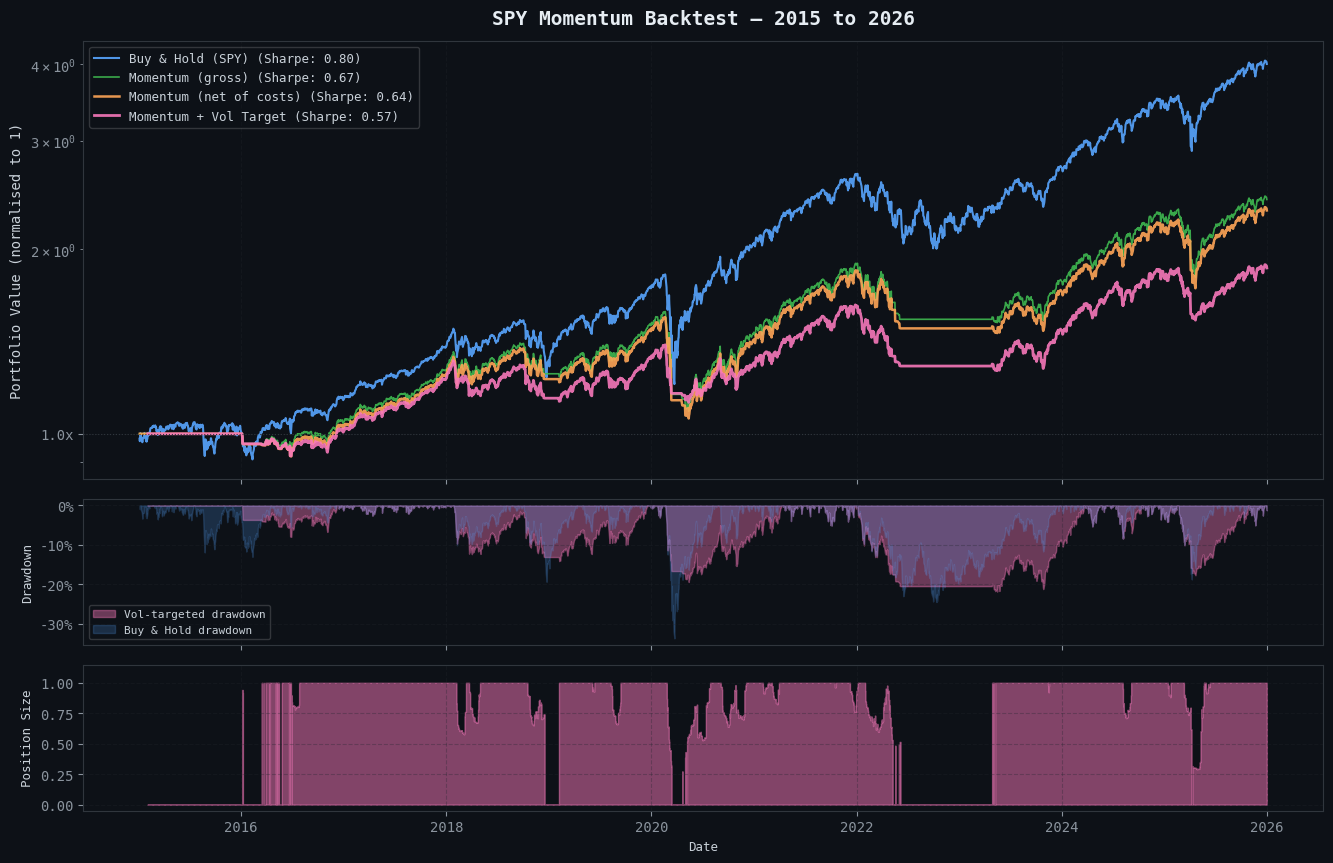

Chart saved as momentum_backtest.png


In [10]:
# ── Main chart: equity curves + drawdown ──────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.08)

ax1 = fig.add_subplot(gs[0])  # equity curves
ax2 = fig.add_subplot(gs[1], sharex=ax1)  # drawdown
ax3 = fig.add_subplot(gs[2], sharex=ax1)  # position

colors = {'bnh': '#58a6ff', 'strat': '#3fb950', 'strat_net': '#ffa657', 'strat_vt': '#f778ba'}

# Equity curves
for v, col, lw in [
    (bnh,       colors['bnh'],      1.5),
    (strat,     colors['strat'],    1.2),
    (strat_net, colors['strat_net'],1.8),
    (strat_vt,  colors['strat_vt'], 2.0),
]:
    ax1.plot(v['cum_series'].index, v['cum_series'].values,
             label=f"{v['label']} (Sharpe: {v['sharpe']:.2f})",
             color=col, linewidth=lw, alpha=0.9)

ax1.axhline(1.0, color='#30363d', linewidth=0.8, linestyle=':')
ax1.set_ylabel('Portfolio Value (normalised to 1)', fontsize=10)
ax1.set_title('SPY Momentum Backtest — 2015 to 2026', fontsize=14, fontweight='bold',
              color='#e6edf3', pad=12)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.2)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}x'))

# Drawdown
ax2.fill_between(strat_vt['dd_series'].index, strat_vt['dd_series'].values,
                 0, color=colors['strat_vt'], alpha=0.4, label='Vol-targeted drawdown')
ax2.fill_between(bnh['dd_series'].index, bnh['dd_series'].values,
                 0, color=colors['bnh'], alpha=0.2, label='Buy & Hold drawdown')
ax2.set_ylabel('Drawdown', fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower left', fontsize=8, framealpha=0.2)

# Position
ax3.fill_between(data.index, data['position_vt'], 0,
                 color=colors['strat_vt'], alpha=0.5, step='post')
ax3.set_ylabel('Position Size', fontsize=9)
ax3.set_ylim(-0.05, 1.15)
ax3.set_xlabel('Date', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

plt.savefig('momentum_backtest.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Chart saved as momentum_backtest.png')

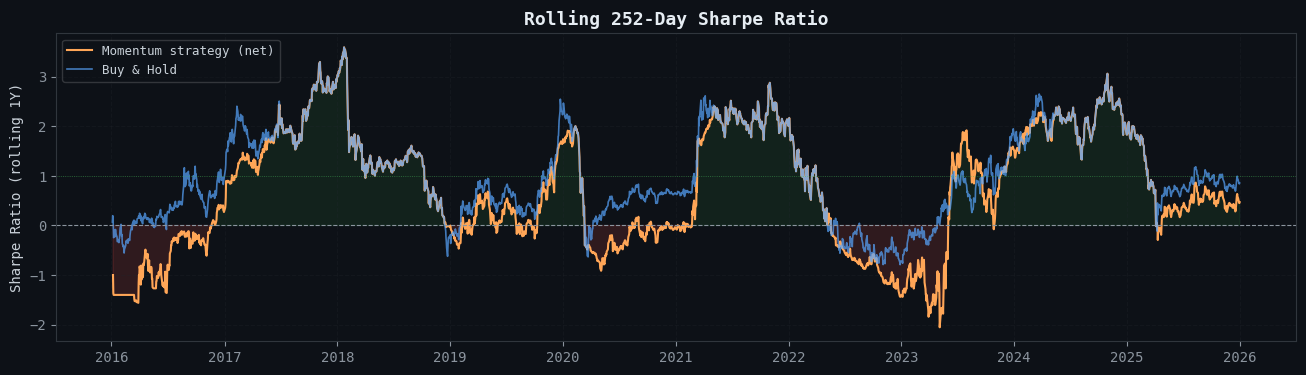

In [11]:
# ── Rolling 252-day Sharpe ratio ──────────────────────────────────────────────
ROLL_WIN = 252

def rolling_sharpe(returns, window):
    mu  = returns.rolling(window).mean() * 252
    vol = returns.rolling(window).std() * np.sqrt(252)
    return mu / vol

rs_strat = rolling_sharpe(data['strategy_return_net'], ROLL_WIN)
rs_bnh   = rolling_sharpe(data['return'], ROLL_WIN)

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(rs_strat.index, rs_strat.values, color='#ffa657', linewidth=1.5,
        label='Momentum strategy (net)')
ax.plot(rs_bnh.index, rs_bnh.values, color='#58a6ff', linewidth=1.2,
        label='Buy & Hold', alpha=0.7)
ax.axhline(0, color='#8b949e', linewidth=0.8, linestyle='--')
ax.axhline(1, color='#3fb950', linewidth=0.6, linestyle=':', alpha=0.6)
ax.fill_between(rs_strat.index, rs_strat.values, 0,
                where=(rs_strat > 0), color='#3fb950', alpha=0.1)
ax.fill_between(rs_strat.index, rs_strat.values, 0,
                where=(rs_strat < 0), color='#f85149', alpha=0.15)

ax.set_title('Rolling 252-Day Sharpe Ratio', fontsize=13, fontweight='bold', color='#e6edf3')
ax.set_ylabel('Sharpe Ratio (rolling 1Y)')
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, alpha=0.3)

plt.savefig('rolling_sharpe.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

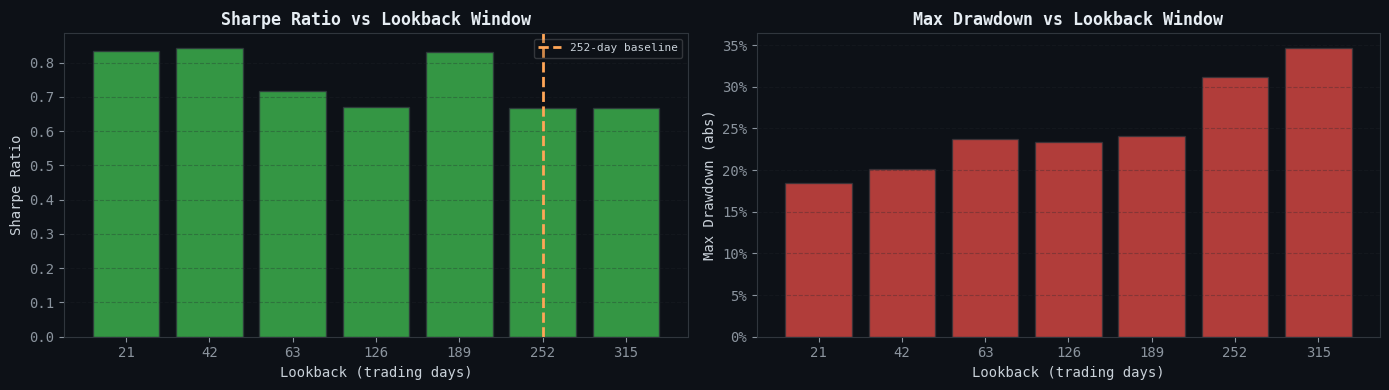

 Lookback (days)  Approx Months  Ann Return  Sharpe  Max Drawdown
              21              1       0.088   0.834        -0.185
              42              2       0.092   0.843        -0.201
              63              3       0.079   0.716        -0.237
             126              6       0.079   0.670        -0.233
             189              9       0.103   0.832        -0.241
             252             12       0.089   0.667        -0.312
             315             15       0.101   0.668        -0.347


In [12]:
# ── Lookback window sensitivity analysis ──────────────────────────────────────
lookbacks = [21, 42, 63, 126, 189, 252, 315]
results   = []

for lb in lookbacks:
    sig = data['close'].pct_change(lb)
    pos = np.where(sig.shift(1) > 0, 1, 0)
    ret = pd.Series(pos * data['return'].values, index=data.index)

    ann_r = ret.mean() * 252
    ann_v = ret.std() * np.sqrt(252)
    shr   = ann_r / ann_v if ann_v > 0 else np.nan

    cum   = (1 + ret).cumprod()
    dd    = ((cum - cum.cummax()) / cum.cummax()).min()

    results.append({'Lookback (days)': lb, 'Approx Months': lb//21,
                    'Ann Return': ann_r, 'Ann Vol': ann_v,
                    'Sharpe': shr, 'Max Drawdown': dd})

df_sens = pd.DataFrame(results)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

bars = ax1.bar([str(r['Lookback (days)']) for r in results],
               [r['Sharpe'] for r in results],
               color=['#f85149' if s < 0 else '#3fb950' for s in df_sens['Sharpe']],
               alpha=0.8, edgecolor='#30363d')
ax1.axvline(x=lookbacks.index(252), color='#ffa657', linewidth=2, linestyle='--', label='252-day baseline')
ax1.set_xlabel('Lookback (trading days)')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe Ratio vs Lookback Window', fontweight='bold', color='#e6edf3')
ax1.legend(fontsize=8, framealpha=0.2)
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar([str(r['Lookback (days)']) for r in results],
        [abs(r['Max Drawdown']) for r in results],
        color='#f85149', alpha=0.7, edgecolor='#30363d')
ax2.set_xlabel('Lookback (trading days)')
ax2.set_ylabel('Max Drawdown (abs)')
ax2.set_title('Max Drawdown vs Lookback Window', fontweight='bold', color='#e6edf3')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lookback_sensitivity.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(df_sens[['Lookback (days)','Approx Months','Ann Return','Sharpe','Max Drawdown']]
      .to_string(index=False, float_format='{:.3f}'.format))

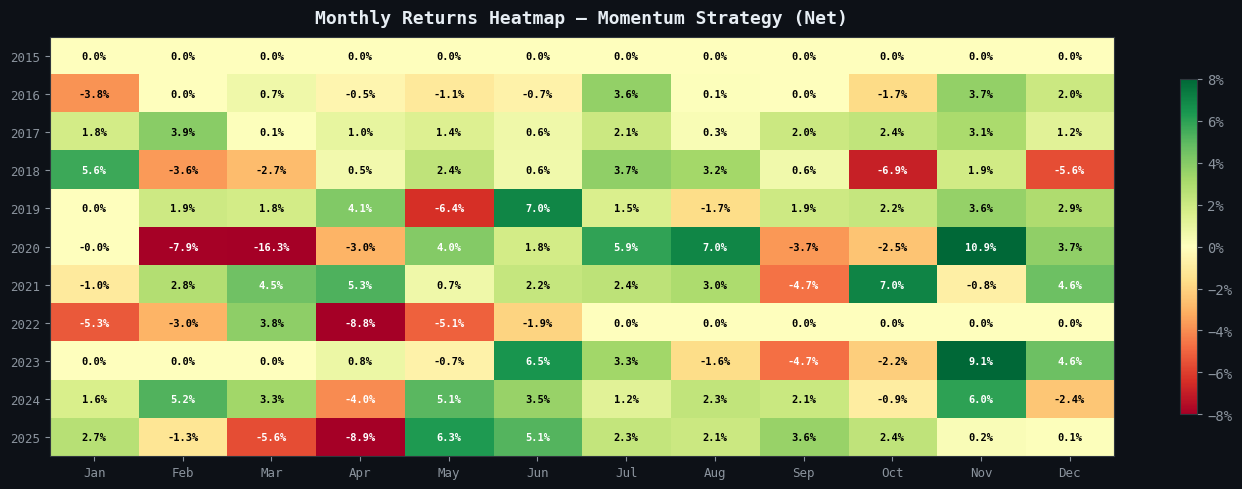

In [13]:
# ── Monthly returns heatmap ────────────────────────────────────────────────────
monthly = data['strategy_return_net'].resample('ME').apply(lambda x: (1+x).prod()-1)
monthly_df = monthly.to_frame()
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot(index='year', columns='month', values='strategy_return_net')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))

vmax = 0.08
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(12))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                    fontsize=7.5, color='black' if abs(val) < 0.04 else 'white',
                    fontweight='bold')

plt.colorbar(im, ax=ax, format='{x:.0%}', shrink=0.8)
ax.set_title('Monthly Returns Heatmap — Momentum Strategy (Net)',
             fontsize=13, fontweight='bold', color='#e6edf3', pad=10)

plt.tight_layout()
plt.savefig('monthly_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()